### **Description**

Recipe showing how to conservatively transform the vertical coordinate system on which a variable is stored using annual-mean outputs from the National Oceanography Centre Near-Present-Day global eORCA1 configuration of NEMO forced using ERA-5 climatologically adjusted atmospheric forcing from 1976-2024.

For more details on this model configuration and the available outputs, users can explore the Near-Present-Day documentation [here](https://noc-msm.github.io/NOC_Near_Present_Day/).

---

In [1]:
# -- Import required packages -- #
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from nemo_cookbook import NEMODataTree

xr.set_options(display_style="text")

### **Using Dask**

**Optional: Connect Client to Dask Local Cluster to run analysis in parallel.**

**Note:** Although using Dask is not strictly necessary for this simple example using eORCA1, if we wanted to generalise this recipe to eORCA025 or eORCA12 outputs, using Dask would be essential to avoid unnecessary slow calculations using only a single process.

In [ ]:
# -- Initialise Dask Local Cluster -- #
import os

import dask
from dask.distributed import Client, LocalCluster

# Update temporary directory for Dask workers:
dask.config.set({'temporary_directory': f"{os.getcwd()}/dask_tmp",
                 'local_directory': f"{os.getcwd()}/dask_tmp"
                 })

# Create Local Cluster:
cluster = LocalCluster(n_workers=4, threads_per_worker=3, memory_limit='5GB')
client = Client(cluster)
client

### **Accessing NEMO Model Data**
**Let's begin by loading the grid variables for our eORCA1 NEMO model from the [JASMIN Object Store](https://help.jasmin.ac.uk/docs/short-term-project-storage/using-the-jasmin-object-store/)**. 

**Alternatively, you can replace the ``domain_filepath`` below with a file path to your domain_cfg.nc file and read this with xarray's ``open_dataset()`` function.**

In [3]:
# Define directory path to ancillary files:
domain_filepath = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/domain_cfg"

# Open eORCA1 NEMO model domain_cfg:
ds_domain = xr.open_zarr(domain_filepath, consolidated=True, chunks={})

ds_domain

<xarray.Dataset> Size: 709MB
Dimensions:       (y: 331, x: 360, nav_lev: 75)
Coordinates:
  * nav_lev       (nav_lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * y             (y) int64 3kB 0 1 2 3 4 5 6 7 ... 324 325 326 327 328 329 330
Data variables: (12/49)
    atlmsk        (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    bathy_metry   (y, x) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    bottom_level  (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1f           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1t           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1u           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    ...            ...
    top_level     (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    umask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    umaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    vmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    vmaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    wmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
Attributes:
    CfgName:    UNKNOWN
    CfgIndex:   -999
    Iperio:     1
    Jperio:     0
    NFold:      1
    NFtype:     F
    VertCoord:  zps
    IsfCav:     0
    file_name:  mesh_mask.nc
    TimeStamp:  01/03/2025 22:19:49 -0000

**Next, we need to import the sea water conservative temperature and absolute salinity stored at T-points in a single dataset.**

In [4]:
# Define directory path to model output files:
gridT_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/T1y"

# Construct NEMO model T-grid dataset, including conservative temperature (degC):
# (Combine 75 vertical levels into single chunk for transforming vertical coordinates with dask)
ds_gridT = xr.open_zarr(gridT_url, consolidated=True, chunks={'deptht': 75}).sel(time_counter=slice('2000-01', '2010-12'))

ds_gridT

<xarray.Dataset> Size: 9GB
Dimensions:                (time_counter: 11, y: 331, x: 360, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lat                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    time_centered          (time_counter) datetime64[ns] 88B dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter           (time_counter) datetime64[ns] 88B 2000-07-02 ... 2...
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/74)
    berg_latent_heat_flux  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    deptht_bounds          (deptht, axis_nbounds) float32 600B dask.array<chunksize=(75, 2), meta=np.ndarray>
    e3t                    (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 75, 331, 360), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    evs                    (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                     ...
    ttrd_qns_li            (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    vohfcisf               (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 75, 331, 360), meta=np.ndarray>
    vohflisf               (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 75, 331, 360), meta=np.ndarray>
    vowflisf               (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 75, 331, 360), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:28:01 GMT
    uuid:         89824b34-5d44-4531-8344-fe1ce39fbb7b

### **Creating a NEMODataTree**

**Next, let's create a NEMODataTree to store our domain and T- & V-grid variables for the eORCA1 model.**

In [5]:
# Define dictionary of grid datasets defining eORCA1 parent model domain with no child/grand-child nests:
datasets = {"parent": {"domain": ds_domain, "gridT": ds_gridT}}

# Initialise a new NEMODataTree whose parent domain is zonally periodic & north-folding on F-points:
nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="F", read_mask=True)

nemo

<xarray.DataTree 'NEMO model'>
Group: /
│   Dimensions:               (time_counter: 11, axis_nbounds: 2)
│   Coordinates:
│       time_centered         (time_counter) datetime64[ns] 88B dask.array<chunksize=(1,), meta=np.ndarray>
│     * time_counter          (time_counter) datetime64[ns] 88B 2000-07-02 ... 20...
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 176B dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 176B dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   F
│       iperio:   True
├── Group: /gridT
│       Dimensions:                (time_counter: 11, j: 331, i: 360, k: 75,
│                                   axis_nbounds: 2)
│       Coordinates:
│         * deptht                 (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
│           time_centered          (time_counter) datetime64[ns] 88B dask.array<chunksize=(1,), meta=np.ndarray>
│           gphit                  (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamt                  (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│         * k                      (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│         * j                      (j) int64 3kB 1 2 3 4 5 6 ... 326 327 328 329 330 331
│         * i                      (i) int64 3kB 1 2 3 4 5 6 ... 355 356 357 358 359 360
│       Dimensions without coordinates: axis_nbounds
│       Data variables: (12/80)
│           berg_latent_heat_flux  (time_counter, j, i) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           deptht_bounds          (k, axis_nbounds) float32 600B dask.array<chunksize=(75, 2), meta=np.ndarray>
│           e3t                    (time_counter, k, j, i) float32 393MB dask.array<chunksize=(1, 75, 331, 360), meta=np.ndarray>
│           empmr                  (time_counter, j, i) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           evs                    (time_counter, j, i) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           ficeberg               (time_counter, j, i) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           ...                     ...
│           e1t                    (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2t                    (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           top_level              (j, i) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           bottom_level           (j, i) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           tmask                  (k, j, i) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
│           tmaskutil              (j, i) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridU
│       Dimensions:       (j: 331, i: 360, k: 75)
│       Coordinates:
│           gphiu         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamu         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│         * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 325 326 327 328 329 330 331
│         * i             (i) float64 3kB 1.5 2.5 3.5 4.5 ... 357.5 358.5 359.5 360.5
│       Data variables:
│           e1u           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2u           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           umask         (k, j, i) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
│           umaskutil     (j, i) int8 119

### **Exploring our eORCA1 NEMO model vertical coordinate system**

Let's begin by visualising the conservative temperature in the original vertical coordinates of our eORCA1 NPD simulation by plotting a vertical profile at a location in the North Atlantic Ocean:


**By examining the vertical profile & the size of the `k` grid coordinate variable, we can see that our eORCA1 configuration has 75 unevenly-spaced z\*-coordinate levels.**

75


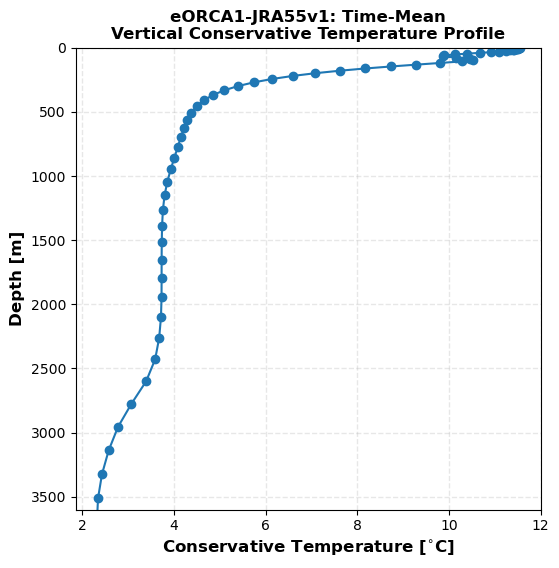

In [6]:
# -- Plot an example time-mean vertical conservative temperature profile in the subpolar North Atlantic -- #
plt.figure(figsize=(6, 6))
plt.grid(True, linewidth=1, linestyle='--', alpha=0.3)
nemo['gridT']['thetao_con'].isel(time_counter=0, i=260, j=260).plot(y='deptht', ylim=(3600, 0), marker='o')

# Axes labels:
plt.title('eORCA1-JRA55v1: Time-Mean\nVertical Conservative Temperature Profile', fontdict={'size':12, 'weight':'bold'})
plt.xlabel('Conservative Temperature [$^{\\circ}$C]', fontdict={'size':12, 'weight':'bold'})
plt.ylabel('Depth [m]', fontdict={'size':12, 'weight':'bold'})

# Size of the vertical coordinate dimension:
print(nemo['gridT']['k'].size)

### **Transforming the eORCA1 vertical coordinate system**

**Next, let's apply a conservative vertical coordinate transformation to remap our conservative temperature output to a new regularly-spaced (200 m) vertical grid:**

In [7]:
# Define our target vertical grid coordinate:
e3t_target = xr.DataArray(np.repeat(200.0, 30), dims=['k_new'])

e3t_target

<xarray.DataArray (k_new: 30)> Size: 240B
array([200., 200., 200., 200., 200., 200., 200., 200., 200., 200., 200.,
       200., 200., 200., 200., 200., 200., 200., 200., 200., 200., 200.,
       200., 200., 200., 200., 200., 200., 200., 200.])
Dimensions without coordinates: k_new

**We will use the `.transform_vertical_grid()` method on a temporal subset of the global conservative temperature field:**

In [8]:
# Transform eORCA1 3-dimensional conservative temperature field to new vertical coordinate system:
ds_k_transform = nemo['gridT/thetao_con'].isel(time_counter=0).transform_vertical_grid(e3_new=e3t_target)

ds_k_transform

<xarray.Dataset> Size: 31MB
Dimensions:        (j: 331, i: 360, k_new: 30)
Coordinates:
    time_counter   datetime64[ns] 8B 2000-07-02
    time_centered  datetime64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
    gphit          (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    glamt          (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
  * j              (j) int64 3kB 1 2 3 4 5 6 7 8 ... 325 326 327 328 329 330 331
  * i              (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
    deptht_new     (k_new) float64 240B 200.0 400.0 600.0 ... 5.8e+03 6e+03
Dimensions without coordinates: k_new
Data variables:
    thetao_con     (k_new, j, i) float32 14MB dask.array<chunksize=(30, 331, 360), meta=np.ndarray>
    e3t_new        (k_new, j, i) float32 14MB dask.array<chunksize=(30, 331, 360), meta=np.ndarray>

Note that the output above returns a Dataset containing two DataArrays: the vertically remapped conservative temperature `thetao_con` and the vertical grid cell thicknesses `e3t_out` (accounting for partial grid cell at the sea floor).

**Since both of these DataArrays contain dask arrays, we haven't actually computed anything yet. To do this, we need to call the ``.compute()`` method:**


In [9]:
ds_k_transform = ds_k_transform.compute()

### **Visualising the vertically transformed conservative temperature field**

**Let's plot the original and vertically transformed conservative temperature profiles together.**

Text(0, 0.5, 'Depth [m]')

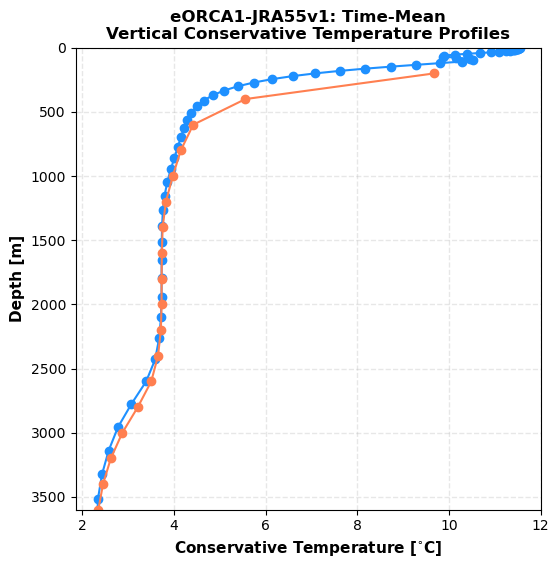

In [10]:
plt.figure(figsize=(6, 6))
plt.grid(True, linewidth=1, linestyle='--', alpha=0.3)

# Plot our original time-mean vertical conservative temperature profile in the subpolar North Atlantic:
nemo['gridT']['thetao_con'].isel(i=260, j=260, time_counter=0).plot(y='deptht', ylim=(3600, 0), marker='o', color='dodgerblue')

# Plot our vertically transformed time-mean vertical conservative temperature profile in the subpolar North Atlantic:
ds_k_transform['thetao_con'].isel(i=260, j=260).plot(y='deptht_new', ylim=(3600, 0), marker='o', color='coral')

# Axis labels:
plt.title('eORCA1-JRA55v1: Time-Mean\nVertical Conservative Temperature Profiles', fontdict={'size':12, 'weight':'bold'})
plt.xlabel('Conservative Temperature [$^{\\circ}$C]', fontdict={'size':11, 'weight':'bold'})
plt.ylabel('Depth [m]', fontdict={'size':11, 'weight':'bold'})

**We can also verify that the product of the vertical grid cell thickness (m) and conservative temperature (C) is conserved following the transformation.**

**Note that we need to transform all variables to a consistent `dtype` (in this case float64) before making the comparison.**

In [11]:
# Calculate the sum of the product of the transformed conservative temperature and cell thickness at our example location:
print((ds_k_transform['thetao_con'].isel(i=260, j=260).astype(np.float64) * ds_k_transform['e3t_new'].isel(i=260, j=260).astype(np.float64)).sum().compute())

# Calculate the sum of the product of the original conservative temperature and cell thickness at our example location:
print((nemo['gridT']['thetao_con'].isel(time_counter=0, i=260, j=260).astype(np.float64) * nemo['gridT']['e3t'].isel(time_counter=0, i=260, j=260).astype(np.float64)).sum().compute())

<xarray.DataArray ()> Size: 8B
array(14272.51116587)
Coordinates:
    time_counter   datetime64[ns] 8B 2000-07-02
    time_centered  datetime64[ns] 8B 2000-07-02
    gphit          float64 8B 51.34
    glamt          float64 8B -26.44
    j              int64 8B 261
    i              int64 8B 261
<xarray.DataArray ()> Size: 8B
array(14272.51116587)
Coordinates:
    time_counter   datetime64[ns] 8B 2000-07-02
    time_centered  datetime64[ns] 8B 2000-07-02
    gphit          float64 8B 51.34
    glamt          float64 8B -26.44
    j              int64 8B 261
    i              int64 8B 261
